Task 1 - Image and Bounding Box

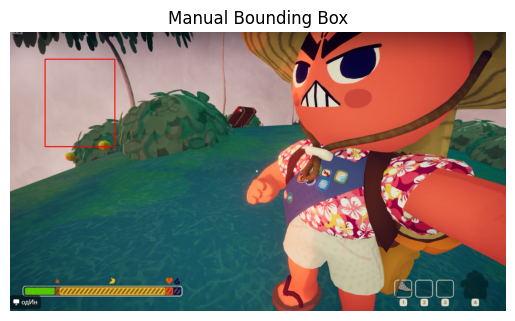

Bounding Box (x, y, width, height): (100, 80, 200, 250)


In [5]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("C:\\Users\\alias\\Downloads\\Peak.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

x, y, w, h = 100, 80, 200, 250

image_copy = image.copy()
cv2.rectangle(image_copy, (x, y), (x+w, y+h), (255, 0, 0), 2)

plt.imshow(image_copy)
plt.title("Manual Bounding Box")
plt.axis("off")
plt.show()

print("Bounding Box (x, y, width, height):", (x, y, w, h))

Task 2 - Pretrained Object Detection

Number of detected objects: 2


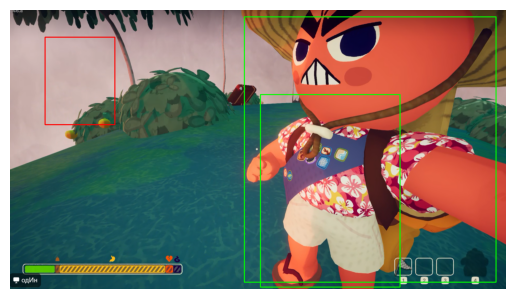

In [6]:
import torch
import torchvision
from torchvision import transforms
from PIL import Image

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()

transform = transforms.Compose([transforms.ToTensor()])
img = Image.open("C:\\Users\\alias\\Downloads\\Peak.png").convert("RGB")
img_tensor = transform(img)

with torch.no_grad():
    predictions = model([img_tensor])

boxes = predictions[0]['boxes']
labels = predictions[0]['labels']
scores = predictions[0]['scores']

threshold = 0.5

detected_count = 0
for i in range(len(scores)):
    if scores[i] > threshold:
        detected_count += 1
        box = boxes[i].numpy().astype(int)
        cv2.rectangle(image_copy, (box[0], box[1]), (box[2], box[3]), (0,255,0), 2)

print("Number of detected objects:", detected_count)

plt.imshow(image_copy)
plt.axis("off")
plt.show()

Task 3 - Confidence Threshold Analysis

In [7]:
thresholds = [0.3, 0.5, 0.8]

for threshold in thresholds:
    count = 0
    for i in range(len(scores)):
        if scores[i] > threshold:
            count += 1
    print(f"Threshold {threshold}: {count} objects detected")

Threshold 0.3: 6 objects detected
Threshold 0.5: 2 objects detected
Threshold 0.8: 0 objects detected


Task 4 - IoU (Intersection over Union)

In [8]:
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union = area1 + area2 - intersection

    return intersection / union

manual_box = [x, y, x+w, y+h]

detected_box = boxes[0].numpy()

iou = compute_iou(manual_box, detected_box)
print("IoU:", iou)

IoU: 0.0


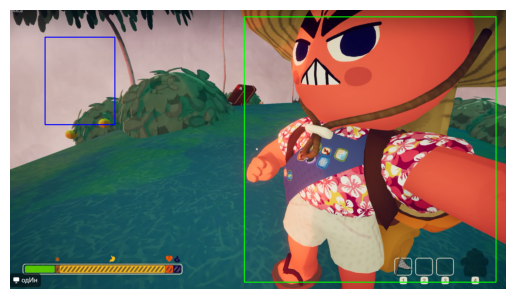

In [ ]:
img_test = image.copy()

cv2.rectangle(img_test, (manual_box[0], manual_box[1]),
              (manual_box[2], manual_box[3]), (0,0,255), 2)

box = detected_box.astype(int)
cv2.rectangle(img_test, (box[0], box[1]),
              (box[2], box[3]), (0,255,0), 2)

plt.imshow(img_test)
plt.axis("off")
plt.show()

In [10]:
best_iou = 0
best_box = None

for box in boxes:
    box = box.numpy()
    iou = compute_iou(manual_box, box)
    if iou > best_iou:
        best_iou = iou
        best_box = box

print("Best IoU:", best_iou)

Best IoU: 0.18312047
